# Solving Systems by Substitution and Elimination

**This notebook teaches how to solve a system of two equations by hand — no prior exposure is assumed.**

A **system of linear equations** is two (or more) equations that must hold at the same time; its **solution** is the pair of values satisfying all of them — the point where the two lines cross. Before we systematize the process (Gaussian elimination, next notebook), it helps to solve small systems the two classic ways: **substitution** and **elimination**. Both are just careful, step-by-step algebra, and both give the same answer.

## Learning objectives

- Solve a two-variable system by **substitution**.
- Solve the same system by **elimination**.
- Check that both methods agree, and see the solution as the point where the lines cross.

## Background

Take the system

$$2x + y = 11, \qquad x + 3y = 18.$$

**Substitution:** solve one equation for one variable, then substitute that expression into the other equation, leaving a single equation in one unknown.

**Elimination:** add or subtract multiples of the equations so that one variable **cancels**, again leaving one equation in one unknown. (Multiplying an equation through by a constant, or adding one equation to another, never changes the solution.)

Both methods reduce a two-variable problem to a one-variable problem you can solve directly.

## This notebook covers

1. The problem, and its picture.
2. The substitution method.
3. The elimination method.
4. Checking the two agree.

**Prerequisites:** `U2-1_Systems-1_GeometryOfSolutions`

**Dataset:** none — the system is entered directly (think of mixing two IV bags to hit two targets).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers

# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. The problem, and its picture

Our system is $2x + y = 11$ and $x + 3y = 18$. Each equation is a line; the solution is where they cross. We write it as an **augmented matrix** (coefficients with the right-hand side) and draw the two lines.

In [2]:
# the coefficients of each equation, and the right-hand sides
coefficients = np.array([[2, 1],
                         [1, 3]])
right_hand_side = np.array([11, 18])

helpers.show_aug(coefficients, right_hand_side, label="the system as an augmented matrix")

<IPython.core.display.Math object>

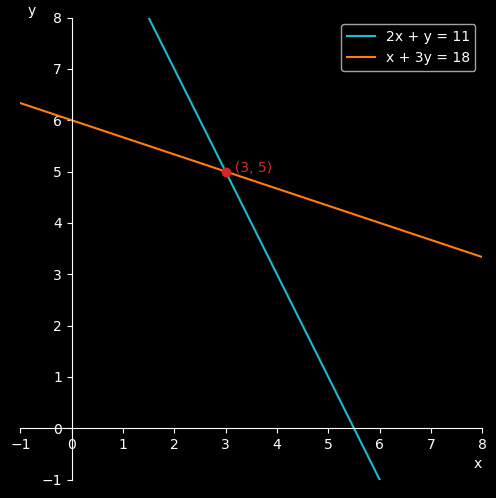

In [3]:
# --- graphics: draw the two lines and their crossing point ---
def line_y(a, bb, c, x):
    return (c - a * x) / bb          # solve a*x + b*y = c for y

x = np.linspace(-1, 8, 100)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x, line_y(2, 1, 11, x), color="tab:cyan", label="2x + y = 11")
ax.plot(x, line_y(1, 3, 18, x), color="tab:orange", label="x + 3y = 18")
ax.plot(3, 5, "o", color="tab:red")          # the solution (found below)
ax.text(3, 5, "  (3, 5)", color="tab:red")
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-1, 8); ax.set_ylim(-1, 8); ax.set_aspect("equal"); ax.legend()
plt.show()

## 2. The substitution method

**Step 1 — solve one equation for one variable.** The first equation $2x + y = 11$ rearranges to

$$y = 11 - 2x.$$

**Step 2 — substitute into the other equation.** Replace $y$ in $x + 3y = 18$:

$$x + 3(11 - 2x) = 18 \;\Rightarrow\; x + 33 - 6x = 18 \;\Rightarrow\; -5x = -15 \;\Rightarrow\; x = 3.$$

**Step 3 — back-substitute** to get $y$: $y = 11 - 2(3) = 5$.

In [4]:
# Step 1: from 2x + y = 11, write y in terms of x:  y = 11 - 2x
# Step 2: substitute into x + 3y = 18 and solve for x.
#   x + 3*(11 - 2x) = 18  ->  x + 33 - 6x = 18  ->  -5x = -15
x = (18 - 33) / (-5)
# Step 3: back-substitute to get y
y = 11 - 2 * x

print("substitution gives  x =", x, " y =", y)
helpers.show(np.array([x, y]), name="solution")

substitution gives  x = 3.0  y = 5.0


<IPython.core.display.Math object>

## 3. The elimination method

Now solve the *same* system by cancelling a variable. Line up the equations and make the $x$-coefficients match so subtraction removes $x$.

**Step 1 — scale.** Multiply the second equation by 2: $\;2x + 6y = 36$.

**Step 2 — subtract** the first equation from it: $\;(2x + 6y) - (2x + y) = 36 - 11$, i.e. $5y = 25$, so $y = 5$.

**Step 3 — back-substitute:** $2x + 5 = 11 \Rightarrow x = 3$.

In [5]:
# Step 1: multiply equation 2 (x + 3y = 18) by 2  ->  2x + 6y = 36
# Step 2: subtract equation 1 (2x + y = 11) to cancel x:
#   (2x + 6y) - (2x + y) = 36 - 11  ->  5y = 25
y = (36 - 11) / 5
# Step 3: back-substitute into 2x + y = 11
x = (11 - y) / 2

print("elimination gives  x =", x, " y =", y)

elimination gives  x = 3.0  y = 5.0


## 4. Checking the two agree

Both methods give $(x, y) = (3, 5)$. Substituting back into the original equations confirms it: $2(3) + 5 = 11$ and $3 + 3(5) = 18$.

In [6]:
x, y = 3, 5
print("2x + y =", 2 * x + y, "(should be 11)")
print("x + 3y =", x + 3 * y, "(should be 18)")

2x + y = 11 (should be 11)
x + 3y = 18 (should be 18)


## 5. Summary

- A two-variable system's **solution** is where the two lines cross.
- **Substitution:** solve one equation for a variable, plug it into the other, solve, back-substitute.
- **Elimination:** scale and subtract equations to cancel a variable, solve, back-substitute.
- Both give the same answer.

For bigger systems, doing this bookkeeping on a grid of numbers is cleaner and more systematic — that is **Gaussian elimination** (`U2-1_Systems-3_GaussianElimination`).